## Prelude

Click "Run All" if notebook is not already populated with graphs.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time, os, sys

sys.path.append(os.path.abspath("./src"))

from pseudorandom_numbers import random
from fixed_point import fpi
from interpolations import interp
from integrals_roots import integrals

plt.rcParams['figure.figsize'] = [6.0, 3.8]  


## Integrals

Often times, even if we have a function which is discrite on all $x$, it does not have a defined integral. The most important example of this is in the equation for normal distribution:

$$\text{pdf}(x) = \frac{1}{\sqrt{2\pi}}e^{-t^2/2}$$

As a norm cdf (used everywhere in stats) is exactly the integral of this function, it is important that we are able to compute an approximation for it (as well as many others).

The first way to go about this is naive, but also most commonly used: take a sample of points across the function, average them and multiply it by the range.

$$\int_a^b f(x) \approx \Delta x (f(x_1) + f(x_2) + \ldots + f(x_n)$$

For $n$ evenly spaced numbers on $[a, b]$

This is called the "midpoint approximation," and is accurate, fast, and practical especially for low-dimension functions.

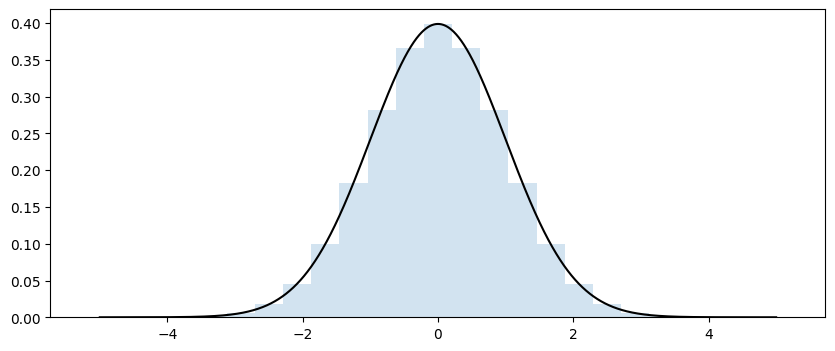

In [21]:
n = 25

pdf = lambda x: (
    (np.exp(-x**2 / 2)) / 
    (np.sqrt(2*np.pi))
)

x = np.linspace(-5, 5, 10_000)
x_sampled = np.linspace(-5, 5, n)

plt.figure(figsize = (10, 4))
plt.plot(x, pdf(x), color = "black")
plt.bar(x_sampled, pdf(x_sampled), alpha = 0.2, width = 10 / (n - 1))
plt.show()

Using it to approximate the cdf (with a lower bound at -5), we get:

In [22]:
cdf_midpoint = lambda x: (
    integrals.midpoint_area(pdf, -5, x, 10_000)
)

float(cdf_midpoint(0))

0.5000494493187186

$\approx 0.5$

Another, more brute-force method, is to approach the problem from a $Monte \text{ } Carlo$ perspective (random sampling). This is especially useful for higher-dimension functions, where integrals are far less trival.

This method consists of populating a space which you know contains the function (or most of it) with random points, and then multiplying the percentage of points lying within/underneath the function by the magnitude of the area. This method works every time, regardless of how complex the function, but has the obious drawback of being inconsistent.

Bellow is a visualization of the approach using the $LCG$ random number generator from before.

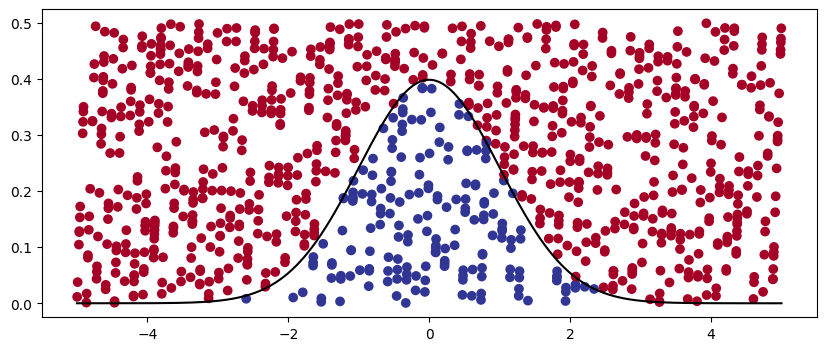

: 

In [ ]:
n = 1000

t = []
y = []
samples = np.zeros(n, dtype = bool)
area = 5

for i in range(n):
    x_i = -5 + random.lcg() * 10
    y_i = random.lcg() * 0.5

    if y_i <= pdf(x_i):
        samples[i] = 1

    t.append(x_i)
    y.append(y_i)

x = np.linspace(-5, 5, 10_000)

plt.figure(figsize = (10, 4))
plt.plot(x, pdf(x), color = "black")
plt.scatter(t, y, c = samples, cmap = 'RdYlBu')
plt.show()

The function below solves for the $\text{cdf}$ using this method.

In [24]:
cdf_monte_carlo = lambda x: (
    integrals.monte_carlo(pdf, -5, x, 10_000)
)

float(
    cdf_monte_carlo(5)
)

1.003882039435337

Sampling from only $10,000$ points, we get a standard deviation of $\approx 1.5\%$, so most Monte Carlo integrations use orders of magnitude more points. (the code block below takes a bit to run)

In [25]:
cdfs = np.zeros(1_000)

for i in range(1_000):
    cdfs[i] = cdf_monte_carlo(5)

print(f"Standard deviation: {(np.std(cdfs) * np.average(cdfs) * 100):.2g}%")

KeyboardInterrupt: 

## Finding Roots

For a variety of reasons in mathematics, we might want to find the roots of a function (or when a function equals any number of interest). There are two main ways of approaching this problem from a computational perspective (assuming you cant solve for them for whatever reason)

The first is known as the bisection method: given two points, which are known to have opposite signs in $f$, take the midpoint and then drop the endpoint with the same ($f$) sign as the midpoint. Then find the midpoint of the midpoint and the remaining starting point, and repeat. This can be acheived recursively simply:

```python
def bisection(f, a, b):
    mid = abs(b - a) + 0.5 * min(a, b)

    if f(a) * f(mid) > 0: # Checks if f(a) and f(mid) are the same sign
        return bisection(f, mid, b)
    else:
        return bisection(f, a, mid)
```

It is essentially just a binary search with an added steps.

Below is an example using this algorithm (using our LCG to find a starting $a$ and $b$) to find where $\text{cdf}(x) = 0.5$ (which we know to be at $0$) stopping when error $\leq 10^{-3}$:

In [ ]:
temp = lambda x: cdf_midpoint(x) - 0.5

integrals.midpoint_iterations = 0

integrals.midpoint_root(temp)

0.0008211457602193229

This takes 10 iterations on average in this case, or more generally $\log_2 N$ iterations, where $N = \frac{(b - a)} {\text{error}}$

In [ ]:
integrals.midpoint_iterations

10

The other method for finding roots is Newton's Method, which takes advantage of the fact that a function in motion tends to stay in motion (hehe get it).

After some initial guess $x_0$, we refine our guess by setting 

$$x_n = x_{n - 1} - \frac{f(x_{n-1})}{f'(x_{n-1})}$$

Essentially taking a linear approximation for the function and then seeing where that linear approximation would equal zero.

For finding the derivative, we simply use the central difference: $f'(x) \approx \frac{f(x + h) - f(x - h)}{2h}$ for small $h$.

Here is an Newton's Method being used to solve the same problem from before.

In [ ]:
integrals.newton_iterations = 0

float(integrals.newton_root(temp))

3363405224.944487

This method only takes 3 iterations in this case, and it is faster in most instances, but has no single method defining the number of iterations it takes.

In [ ]:
integrals.newton_iterations

2

The error is also much lower for Newton's Method, despite the fact that both have the same stopping error, which will in many instances be the case, but is also a symptom of $\text{cdf}$ being linear at $x = 0$.